# Framing Drift Over Time

Analyzing how frame usage changes over time, globally and by topic.

In [1]:
!pip install pandas numpy matplotlib seaborn pyarrow scipy

zsh:1: command not found: pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_parquet('../data/merged_topic_and_frames_filtered.parquet')
df['date'] = pd.to_datetime(df['date'])
df['quarter'] = df['date'].dt.to_period('Q')
print(f'Loaded {len(df):,} articles')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

frames = sorted(['economic', 'fairness', 'public_op', 'political', 'quality_life',
                 'crime', 'culture', 'health', 'legality', 'morality',
                 'policy', 'regulation', 'security', 'cap&res'])

frame_matrix = np.array(df['vector'].tolist())
for i, frame in enumerate(frames):
    df[f'frame_{frame}'] = frame_matrix[:, i]

frame_cols = [f'frame_{f}' for f in frames]

Loaded 80,783 articles
Date range: 2015-01-01 to 2021-12-31


## Global Frame Drift Over Time

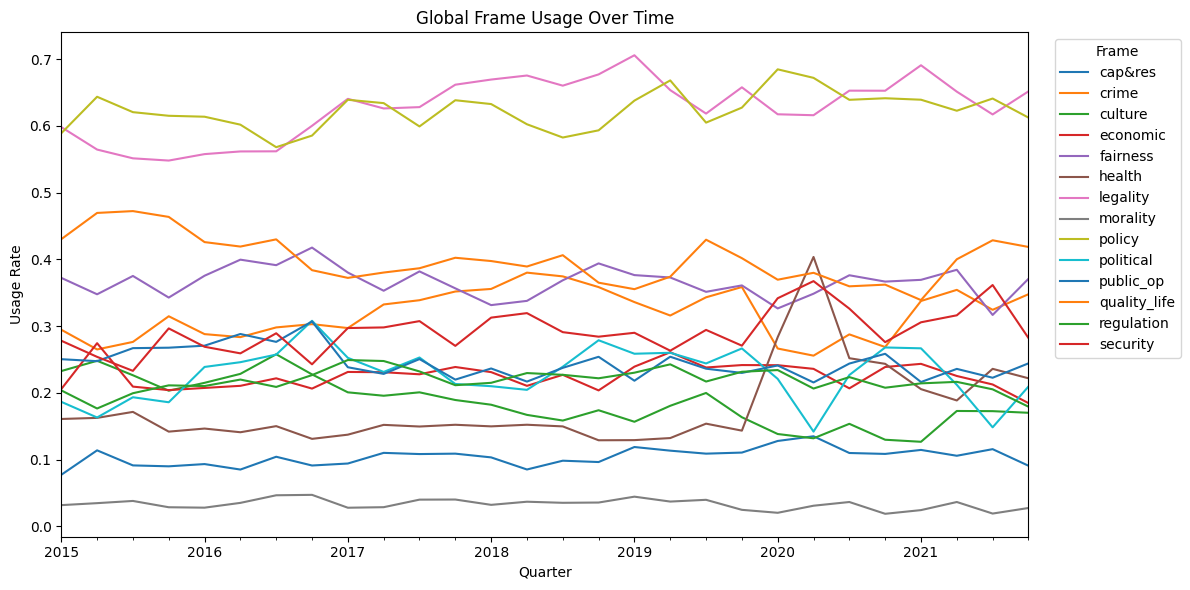

In [3]:
quarterly_global = df.groupby('quarter')[frame_cols].mean()

fig, ax = plt.subplots(figsize=(12, 6))
quarterly_global.plot(ax=ax)
plt.title('Global Frame Usage Over Time')
plt.xlabel('Quarter')
plt.ylabel('Usage Rate')
plt.legend(labels=frames, bbox_to_anchor=(1.02, 1), title='Frame')
plt.tight_layout()
plt.show()

In [4]:
# linear regression to measure trend
x = np.arange(len(quarterly_global))

trends = []
for frame_col in frame_cols:
    y = quarterly_global[frame_col].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    trends.append({
        'frame': frame_col.replace('frame_', ''),
        'slope_per_quarter': slope,
        'slope_per_year': slope * 4,
        'r_squared': r_value ** 2,
        'p_value': p_value
    })

trend_df = pd.DataFrame(trends).sort_values('slope_per_year', key=abs, ascending=False)
trend_df.style.format({
    'slope_per_quarter': '{:+.2%}',
    'slope_per_year': '{:+.2%}',
    'r_squared': '{:.3f}',
    'p_value': '{:.4f}'
})

,frame,slope_per_quarter,slope_per_year,r_squared,p_value
5,health,+0.40%,+1.59%,0.288,0.0032
2,culture,-0.36%,-1.43%,0.678,0.0000
6,legality,+0.36%,+1.42%,0.421,0.0002
11,quality_life,-0.23%,-0.92%,0.296,0.0028
13,security,+0.22%,+0.87%,0.314,0.0019
10,public_op,-0.14%,-0.58%,0.273,0.0044
8,policy,+0.14%,+0.56%,0.169,0.0300
1,crime,+0.12%,+0.47%,0.072,0.1659
0,cap&res,+0.09%,+0.35%,0.283,0.0036
4,fairness,-0.07%,-0.26%,0.056,0.2259


## Frame Drift by Topic

In [5]:
topics = df['topic_top1'].value_counts().index.tolist()
print(f'Topics: {topics}')

Topics: ['elections and politics', 'crime', 'entertainment', 'technology', 'finance', 'pandemic', 'healthcare', 'Middle East', 'immigration', 'China', 'Russia']


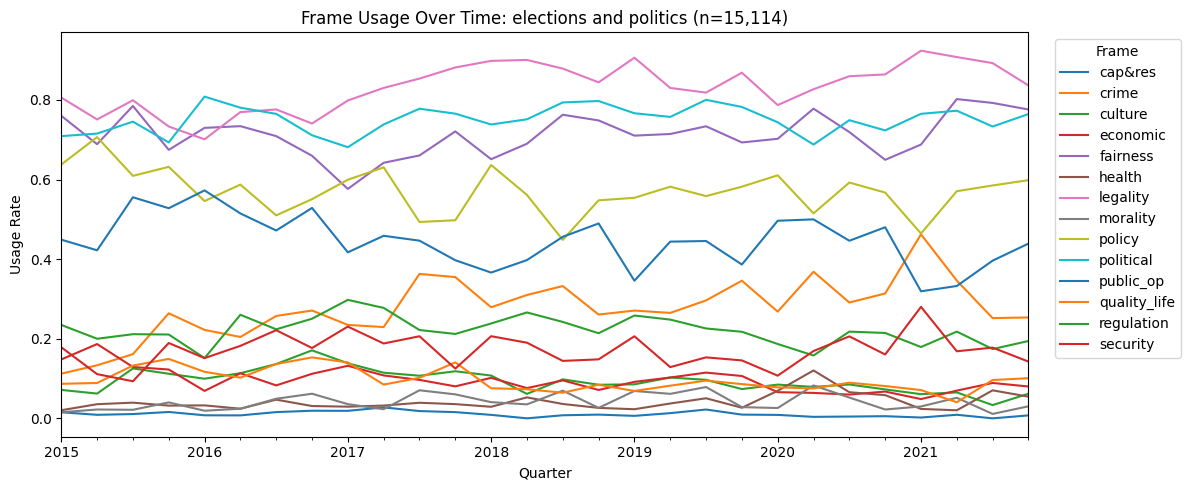

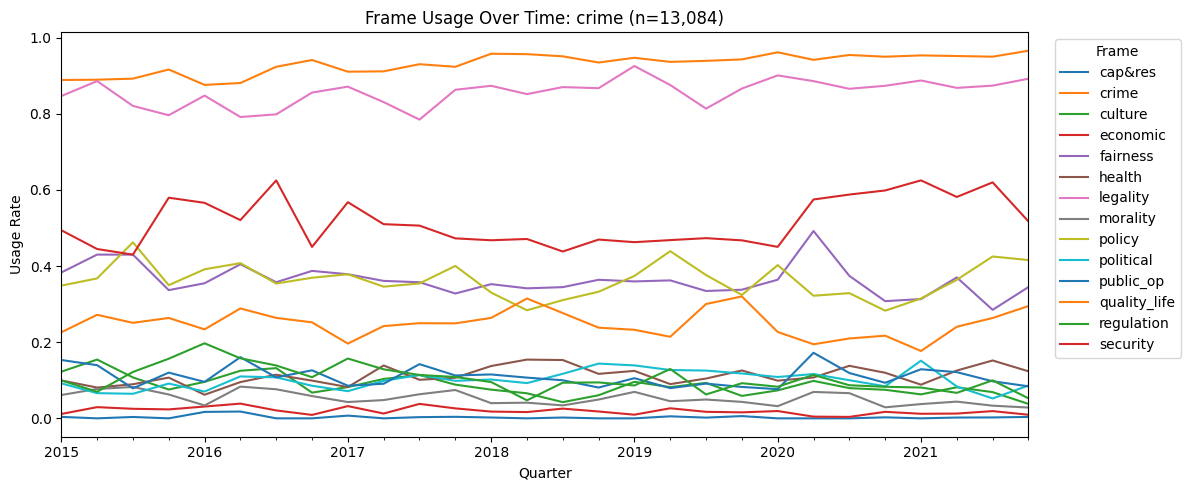

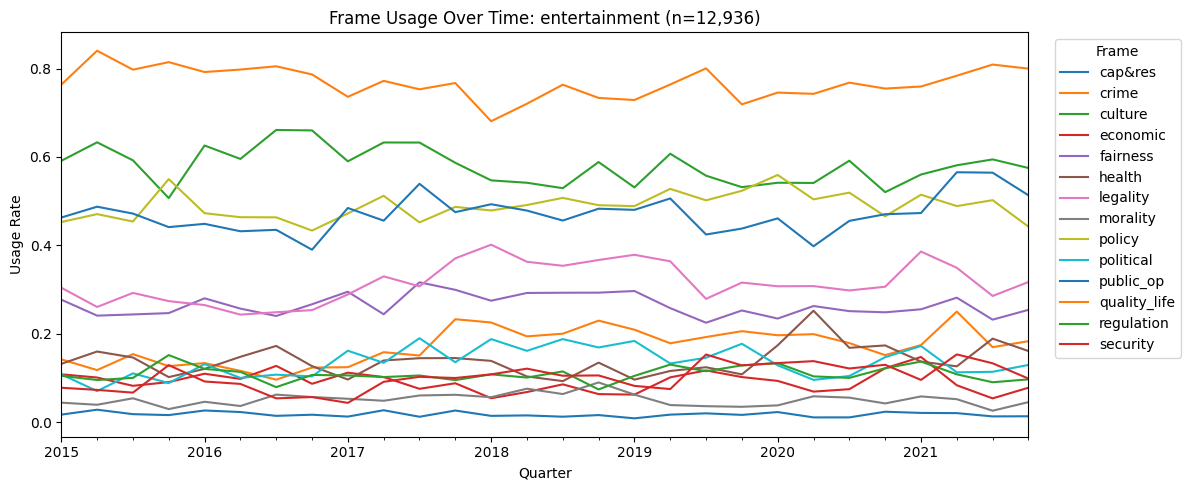

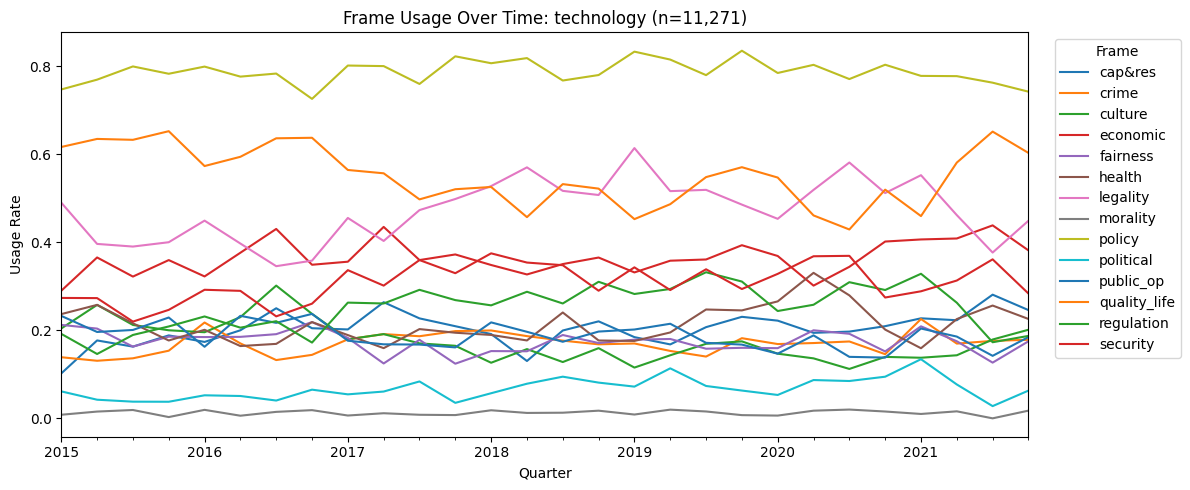

In [6]:
def plot_topic_drift(topic):
    subset = df[df['topic_top1'] == topic]
    quarterly = subset.groupby('quarter')[frame_cols].mean()
    
    fig, ax = plt.subplots(figsize=(12, 5))
    quarterly.plot(ax=ax)
    plt.title(f'Frame Usage Over Time: {topic} (n={len(subset):,})')
    plt.xlabel('Quarter')
    plt.ylabel('Usage Rate')
    plt.legend(labels=frames, bbox_to_anchor=(1.02, 1), title='Frame')
    plt.tight_layout()
    plt.show()

for topic in topics[:4]:
    plot_topic_drift(topic)

In [7]:
# trend by topic
topic_trends = []
for topic in topics:
    subset = df[df['topic_top1'] == topic]
    quarterly = subset.groupby('quarter')[frame_cols].mean()
    x = np.arange(len(quarterly))
    
    for frame_col in frame_cols:
        y = quarterly[frame_col].values
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        topic_trends.append({
            'topic': topic,
            'frame': frame_col.replace('frame_', ''),
            'slope_per_year': slope * 4,
            'p_value': p_value
        })

topic_trend_df = pd.DataFrame(topic_trends)
pivot = topic_trend_df.pivot(index='topic', columns='frame', values='slope_per_year')
pivot.style.format('{:+.1%}').background_gradient(cmap='PiYG', vmin=-0.05, vmax=0.05)

frame,cap&res,crime,culture,economic,fairness,health,legality,morality,policy,political,public_op,quality_life,regulation,security
topic,,,,,,,,,,,,,,
China,-2.3%,+1.6%,-1.7%,-3.5%,+2.0%,+2.0%,+4.5%,+0.4%,-1.1%,+1.0%,+0.0%,-2.0%,+3.6%,+3.0%
Middle East,+0.1%,-2.3%,-1.5%,+0.2%,-0.5%,+0.6%,+1.3%,-0.3%,+0.7%,+0.4%,-0.6%,-0.6%,+2.5%,+0.5%
Russia,+0.9%,-1.3%,-2.1%,+0.8%,-1.4%,+2.2%,+0.1%,-0.6%,+1.5%,-1.8%,-1.8%,-0.6%,-0.5%,+0.1%
crime,-0.1%,+1.1%,-0.8%,-0.2%,-0.7%,+0.5%,+0.9%,-0.5%,-0.3%,+0.3%,-0.3%,-0.2%,-1.0%,+0.9%
elections and politics,-0.2%,+2.3%,-0.8%,-1.0%,+0.7%,+0.4%,+1.9%,+0.2%,-0.8%,+0.3%,-1.5%,-0.8%,-0.5%,+0.2%
entertainment,-0.1%,+1.2%,-0.8%,-0.2%,-0.2%,+0.5%,+0.9%,-0.0%,+0.5%,+0.4%,+0.7%,-0.4%,+0.1%,+0.9%
finance,+0.4%,-0.2%,-0.5%,+0.8%,-0.8%,+0.5%,+0.6%,-0.1%,+0.7%,-0.1%,-0.0%,+1.0%,+0.3%,+0.3%
healthcare,+0.8%,-0.1%,-0.4%,-0.4%,-1.7%,+1.5%,+2.7%,-0.0%,+0.6%,-0.4%,+0.2%,-3.4%,+1.2%,+1.5%
immigration,+0.3%,+3.7%,-2.9%,+0.1%,+0.2%,+0.7%,+3.1%,-0.6%,+0.6%,-0.8%,-1.4%,-2.1%,-0.9%,+3.1%


In [8]:
# Summary of per-topic trend magnitudes
print('Summary of per-topic frame drift magnitudes:\n')

# Get absolute slopes for each topic-frame combination
abs_slopes = topic_trend_df['slope_per_year'].abs()
print(f'Overall range of per-topic trends: {abs_slopes.min():.1%} to {abs_slopes.max():.1%} per year')
print(f'Median absolute trend: {abs_slopes.median():.1%} per year')
print(f'Mean absolute trend: {abs_slopes.mean():.1%} per year')

# Show topics with largest trends
print('\nTopics with largest frame trends (any frame):')
max_by_topic = topic_trend_df.groupby('topic')['slope_per_year'].apply(lambda x: x.abs().max())
for topic in max_by_topic.sort_values(ascending=False).head(5).index:
    max_val = max_by_topic[topic]
    print(f'  {topic}: up to {max_val:.1%}/year')

# Count how many topic-frame combinations exceed thresholds
print(f'\nTopic-frame combinations with |trend| > 3%/year: {(abs_slopes > 0.03).sum()} of {len(abs_slopes)}')
print(f'Topic-frame combinations with |trend| > 5%/year: {(abs_slopes > 0.05).sum()} of {len(abs_slopes)}')

Summary of per-topic frame drift magnitudes:

Overall range of per-topic trends: 0.0% to 4.7% per year
Median absolute trend: 0.8% per year
Mean absolute trend: 1.1% per year

Topics with largest frame trends (any frame):
  pandemic: up to 4.7%/year
  China: up to 4.5%/year
  immigration: up to 3.7%/year
  healthcare: up to 3.4%/year
  Middle East: up to 2.5%/year

Topic-frame combinations with |trend| > 3%/year: 12 of 154
Topic-frame combinations with |trend| > 5%/year: 0 of 154


## Frame Drift by Outlet (for selected topic)

In [9]:
selected_topic = 'elections and politics'
topic_df = df[df['topic_top1'] == selected_topic]
print(f'Analyzing: {selected_topic} ({len(topic_df):,} articles)')
print(f'\nArticles per outlet:')
print(topic_df['outlet_name'].value_counts())

Analyzing: elections and politics (15,114 articles)

Articles per outlet:
outlet_name
Breitbart News         4521
Newsweek               4251
HuffPost               1691
Washington Times       1625
New York Post           924
The Washington Post     778
CNBC                    660
Reuters                 583
BBC News                 81
Name: count, dtype: int64


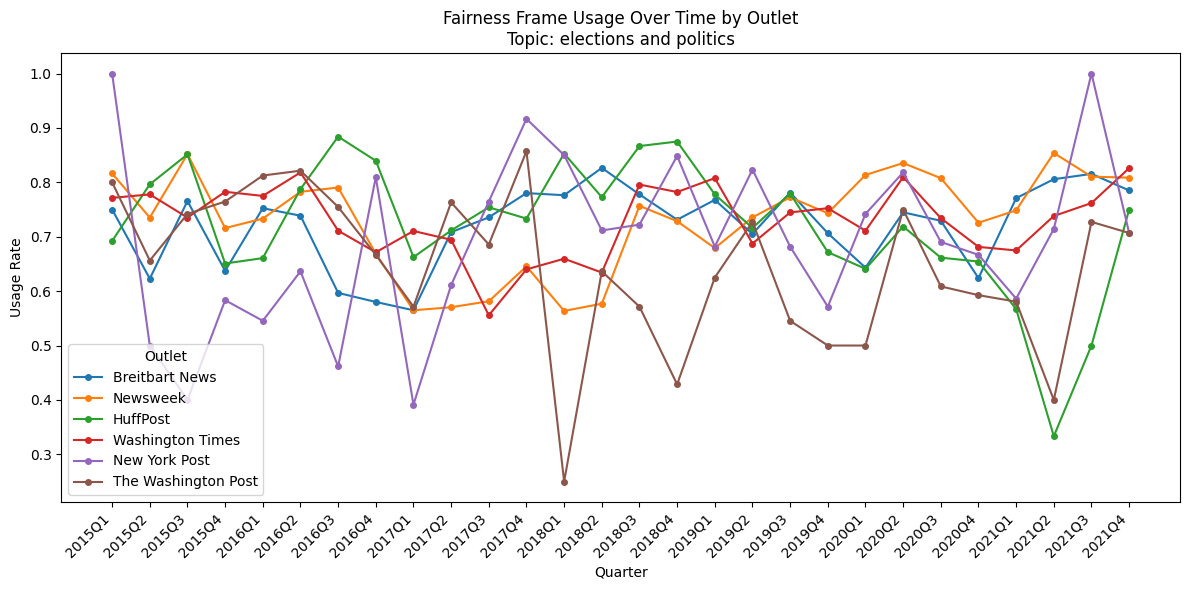

In [10]:
selected_frame = 'fairness'
frame_col = f'frame_{selected_frame}'
outlets = topic_df['outlet_name'].value_counts().head(6).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
for outlet in outlets:
    outlet_df = topic_df[topic_df['outlet_name'] == outlet]
    quarterly = outlet_df.groupby('quarter')[frame_col].mean()
    ax.plot(quarterly.index.astype(str), quarterly.values, label=outlet, marker='o', markersize=4)

plt.title(f'{selected_frame.title()} Frame Usage Over Time by Outlet\nTopic: {selected_topic}')
plt.xlabel('Quarter')
plt.ylabel('Usage Rate')
plt.legend(title='Outlet')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

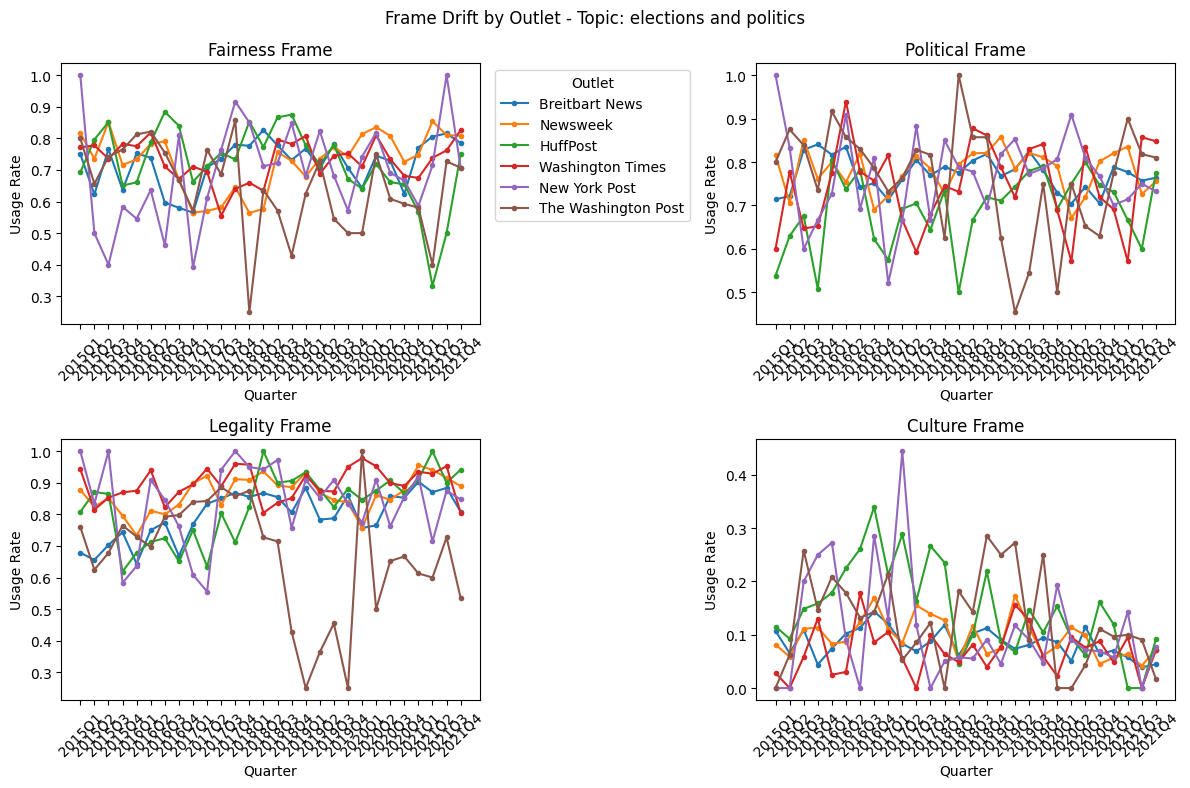

In [11]:
key_frames = ['fairness', 'political', 'legality', 'culture']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, frame in enumerate(key_frames):
    frame_col = f'frame_{frame}'
    ax = axes[idx]
    
    for outlet in outlets:
        outlet_df = topic_df[topic_df['outlet_name'] == outlet]
        quarterly = outlet_df.groupby('quarter')[frame_col].mean()
        ax.plot(quarterly.index.astype(str), quarterly.values, label=outlet, marker='o', markersize=3)
    
    ax.set_title(f'{frame.title()} Frame')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Usage Rate')
    ax.tick_params(axis='x', rotation=45)

axes[0].legend(title='Outlet', bbox_to_anchor=(1.02, 1))
plt.suptitle(f'Frame Drift by Outlet - Topic: {selected_topic}', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
outlet_stats = []
for outlet in outlets:
    outlet_df = topic_df[topic_df['outlet_name'] == outlet]
    for frame in key_frames:
        frame_col = f'frame_{frame}'
        quarterly = outlet_df.groupby('quarter')[frame_col].mean()
        outlet_stats.append({
            'outlet': outlet,
            'frame': frame,
            'mean': quarterly.mean(),
            'std': quarterly.std(),
            'range': quarterly.max() - quarterly.min()
        })

outlet_stats_df = pd.DataFrame(outlet_stats)

for col in ['mean', 'std', 'range']:
    print(f'{col.upper()} frame usage over time:')
    pivot = outlet_stats_df.pivot(index='outlet', columns='frame', values=col)
    display(pivot.style.format('{:.1%}').background_gradient(cmap='Blues', axis=None))
    print()

MEAN frame usage over time:


frame,culture,fairness,legality,political
outlet,,,,
Breitbart News,8.5%,72.2%,79.8%,77.2%
HuffPost,14.8%,72.0%,82.9%,69.0%
New York Post,10.9%,69.4%,83.8%,76.8%
Newsweek,9.5%,72.9%,86.6%,78.0%
The Washington Post,12.6%,64.4%,66.5%,76.2%
Washington Times,7.0%,73.0%,89.6%,74.5%



STD frame usage over time:


frame,culture,fairness,legality,political
outlet,,,,
Breitbart News,2.7%,7.4%,7.6%,4.1%
HuffPost,8.5%,12.1%,10.6%,8.6%
New York Post,10.4%,15.9%,12.7%,10.1%
Newsweek,3.6%,9.1%,5.6%,5.0%
The Washington Post,8.9%,14.2%,18.9%,12.8%
Washington Times,4.5%,6.5%,5.2%,10.0%



RANGE frame usage over time:


frame,culture,fairness,legality,political
outlet,,,,
Breitbart News,10.5%,26.2%,26.0%,13.7%
HuffPost,34.0%,55.1%,38.1%,30.4%
New York Post,44.4%,60.9%,44.4%,47.8%
Newsweek,13.1%,29.0%,22.2%,18.7%
The Washington Post,28.6%,60.7%,75.0%,54.5%
Washington Times,17.8%,27.1%,17.3%,36.8%
